### Group Visualizations

In [3]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np
import pandas as pd

from src.config import PROCESSED_DATA_DIR

In [5]:
PHASE_ORDER = ["Menstrual", "Follicular", "Fertility", "Luteal"]
PHASE_COLORS = {
    "Menstrual": "#ca0020",
    "Follicular": "#ef8a62",
    "Fertility": "#67a9cf",
    "Luteal": "#0571b0",
}
REPORT_COLS = [
    "appetite", "exerciselevel", "headaches", "cramps", "sorebreasts",
    "fatigue", "sleepissue", "moodswing", "stress", "foodcravings",
    "indigestion", "bloating",
]

def ci95(series):
    n = series.count()
    if n < 2:
        return float("nan")
    return 1.96 * series.std() / np.sqrt(n)

In [6]:
interday = pd.read_csv(PROCESSED_DATA_DIR / "features_interday.csv")
intraday = pd.read_csv(PROCESSED_DATA_DIR / "features_intraday.csv", parse_dates=["datetime"])

print(f"Interday: {interday.shape}")
print(f"Intraday: {intraday.shape}")

Interday: (3230, 51)
Intraday: (847872, 15)


In [7]:
print(f"All cycles: {interday.groupby(['id','cycle_id']).ngroups}  |  subjects: {interday['id'].nunique()}")
interday = interday[interday["is_complete_cycle"]].copy()
complete_pairs = interday[["id", "cycle_id"]].drop_duplicates()
intraday = intraday.merge(complete_pairs, on=["id", "cycle_id"])
print(f"Complete cycles: {interday.groupby(['id','cycle_id']).ngroups}  |  subjects: {interday['id'].nunique()}")

All cycles: 126  |  subjects: 38
Complete cycles: 88  |  subjects: 37


### Cycle length and phase duration distributions

Cycle length (days): mean = 29.33, sd = 5.57


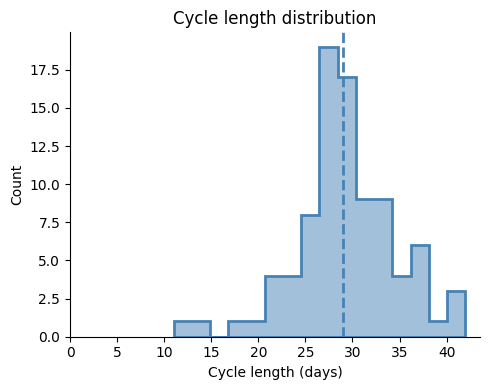

In [8]:
cycle_lengths = interday.groupby(["id", "cycle_id"])["cycle_day"].max()
print(f"Cycle length (days): mean = {cycle_lengths.mean():0.2f}, sd = {cycle_lengths.std():0.2f}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(cycle_lengths, bins=16, 
        histtype="stepfilled",
        facecolor=mcolors.to_rgba("steelblue", alpha=0.5),
        edgecolor="steelblue", 
        linewidth=2)
ax.axvline(cycle_lengths.median(), color="steelblue", linewidth=2, linestyle="--")
ax.set_xlabel("Cycle length (days)")
ax.set_ylabel("Count")
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(0, None)
ax.set_title("Cycle length distribution")
fig.tight_layout()
plt.show()

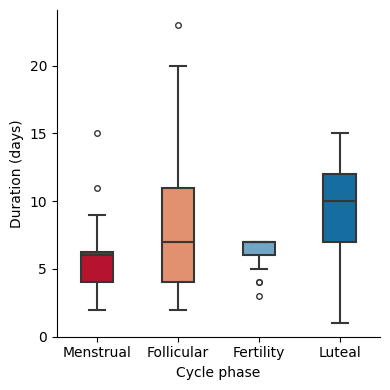

In [9]:
phase_dur = (
    interday.dropna(subset=["phase"])
    .groupby(["id", "cycle_id", "phase"])
    .size()
    .reset_index(name="days")
)

fig, ax = plt.subplots(figsize=(4, 4))
sns.boxplot(data=phase_dur, x="phase", y="days",
            hue="phase", palette=PHASE_COLORS, fill=True, saturation=0.8,
            linecolor="auto", linewidth=1.5, width=0.4, order=PHASE_ORDER,
            flierprops={"markersize": 4})

ax.set_xlabel("Cycle phase")
ax.set_ylabel("Duration (days)")
ax.set_ylim(0, None)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

### Hormones by cycle phase

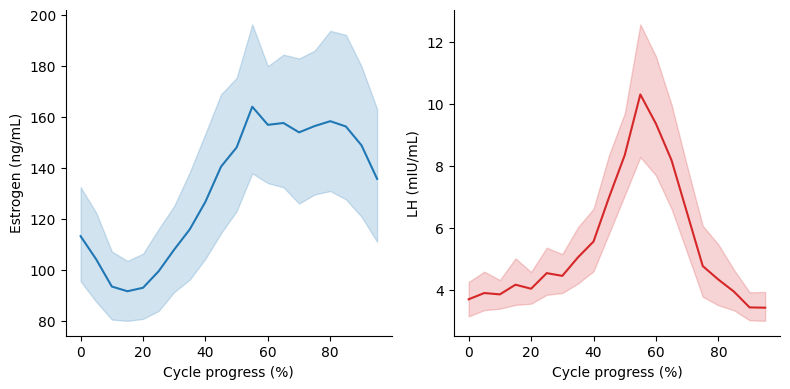

In [10]:
df = interday.dropna(subset=["estrogen_smooth", "lh_smooth"]).copy()

by_pct = (
    df.groupby(["id", "cycle_pct_bin"])[["estrogen_smooth", "lh_smooth"]].median()
    .reset_index()
)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
sns.lineplot(data=by_pct, x="cycle_pct_bin", y="estrogen_smooth", ax=ax[0])
sns.lineplot(data=by_pct, x="cycle_pct_bin", y="lh_smooth", color="tab:red", ax=ax[1])

for i in range(0, 2):
    ax[i].set_xlabel("Cycle progress (%)")
    ax[i].spines[["top", "right"]].set_visible(False)

ax[0].set_ylabel("Estrogen (ng/mL)")
ax[1].set_ylabel("LH (mIU/mL)")

fig.tight_layout()
plt.show()

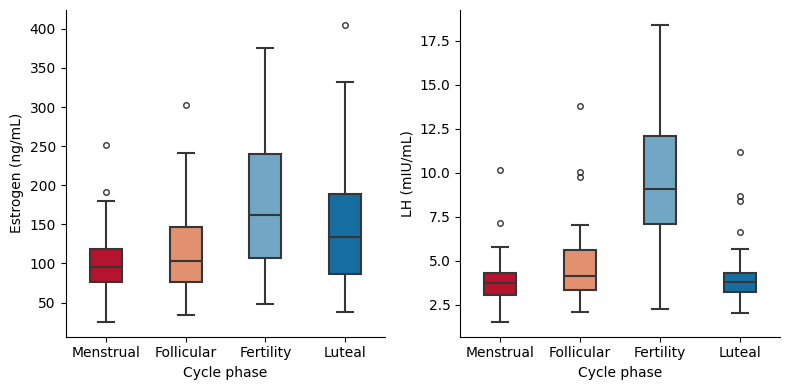

In [11]:
df = interday.dropna(subset=["estrogen_smooth", "lh_smooth"]).copy()

by_phase = (
    df.groupby(["id", "phase"])[["estrogen_smooth", "lh_smooth"]].mean()
    .reset_index()
)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
sns.boxplot(data=by_phase, x="phase", y="estrogen_smooth", ax=ax[0],
            hue="phase", palette=PHASE_COLORS, fill=True, saturation=0.8,
            linecolor="auto", linewidth=1.5, width=0.4, order=PHASE_ORDER,
            flierprops={"markersize": 4})
sns.boxplot(data=by_phase, x="phase", y="lh_smooth", ax=ax[1],
            hue="phase", palette=PHASE_COLORS, fill=True, saturation=0.8,
            linecolor="auto", linewidth=1.5, width=0.4, order=PHASE_ORDER,
            flierprops={"markersize": 4})

for i in range(0, 2):
    ax[i].set_xlabel("Cycle phase")
    ax[i].spines[["top", "right"]].set_visible(False)

ax[0].set_ylabel("Estrogen (ng/mL)")
ax[1].set_ylabel("LH (mIU/mL)")

fig.tight_layout()
plt.show()

### Temperature by cycle phase

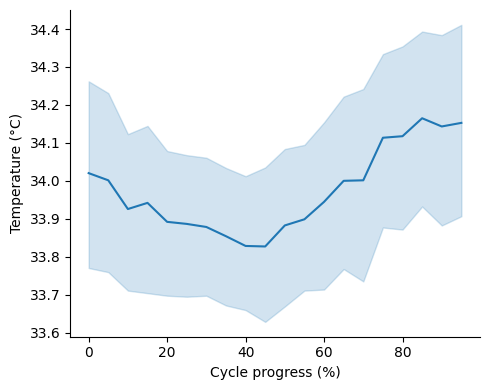

In [12]:
df = interday.copy()
df["temperature_smooth"] = (
        df.groupby(["id"])["temperature"]
        .transform(lambda x: x.rolling(window=10, center=True, min_periods=1).mean())
        .round(1)
    )
by_pct = (
    df.groupby(["id", "cycle_pct_bin"])[["temperature_smooth"]].median()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(5, 4))
sns.lineplot(data=by_pct, x="cycle_pct_bin", y="temperature_smooth")

ax.set_ylabel("Temperature (°C)")
ax.set_xlabel("Cycle progress (%)")
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

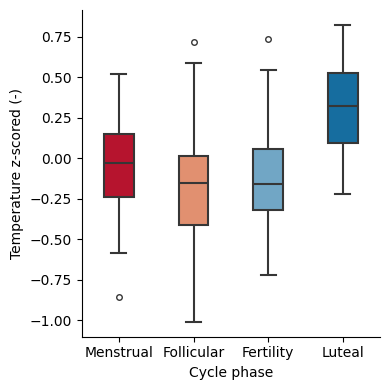

In [13]:
df = interday.dropna(subset=["temperature_z_scored"]).copy()

by_phase = (
    df.groupby(["id", "phase"])[["temperature_z_scored"]].mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(4, 4))
sns.boxplot(data=by_phase, x="phase", y="temperature_z_scored",
            hue="phase", palette=PHASE_COLORS, fill=True, saturation=0.8,
            linecolor="auto", linewidth=1.5, width=0.4, order=PHASE_ORDER,
            flierprops={"markersize": 4})

ax.set_ylabel("Temperature z-scored (-)")
ax.set_xlabel("Cycle phase")
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

### Report scores by cycle phase

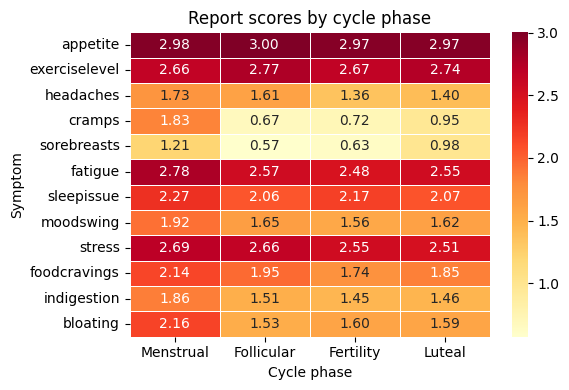

In [14]:
df = interday.copy()
phase_means = df.groupby("phase")[REPORT_COLS].mean().reindex(PHASE_ORDER)

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(phase_means.T, ax=ax, cmap="YlOrRd", annot=True, fmt=".2f", linewidths=0.5)
ax.set_xlabel("Cycle phase")
ax.set_ylabel("Symptom")
ax.set_title("Report scores by cycle phase")
fig.tight_layout()
plt.show()

### Sleep metrics by cycle phase

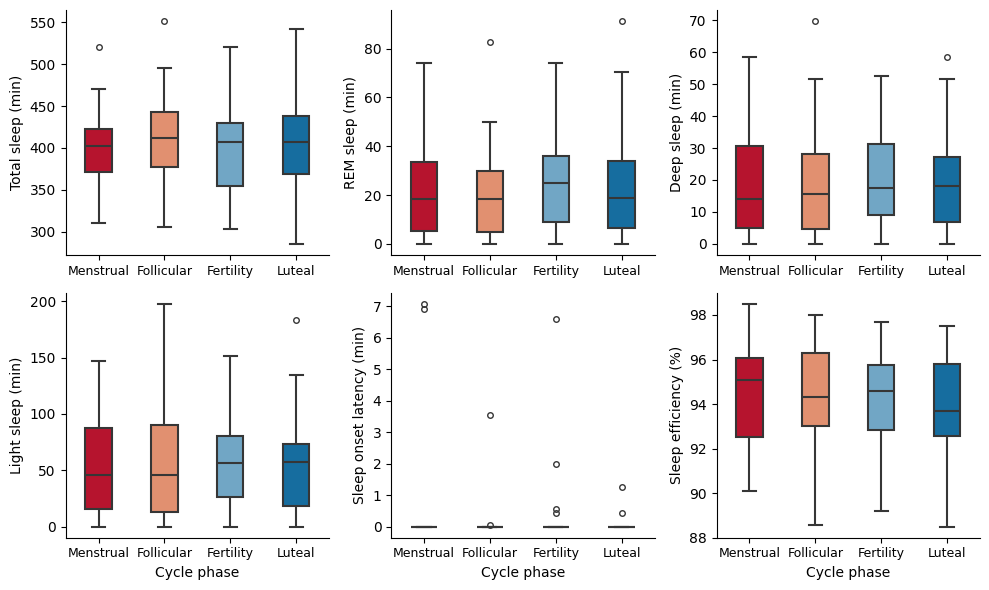

In [24]:
df = interday.copy()
sleep_vars = ["sleep_min_total", "sleep_min_rem", "sleep_min_deep",
              "sleep_min_light", "sleep_onset_latency", "sleep_efficiency"]
ylabels = ["Total sleep (min)", "REM sleep (min)", "Deep sleep (min)",
           "Light sleep (min)", "Sleep onset latency (min)", "Sleep efficiency (%)"]

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
axes = axes.flatten()
for ax, var, ylabel in zip(axes, sleep_vars, ylabels):
    data = df.groupby(["id", "phase"])[[var]].mean()
    sns.boxplot(data=data, x="phase", y=var,
            hue="phase", palette=PHASE_COLORS, fill=True, saturation=0.8,
            linecolor="auto", linewidth=1.5, width=0.4, order=PHASE_ORDER,
            flierprops={"markersize": 4}, ax=ax)    
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", labelsize=9)
    ax.spines[["top", "right"]].set_visible(False)
for i in range(3, 6):
    axes[i].set_xlabel("Cycle phase")

fig.tight_layout()
plt.show()